# 1 - Limites planétaires, AESA et trajectoires mondiales

Ce notebook constitue la première étape du projet de semestre. Nous allons relier trois idées :

1. les **limites planétaires** décrivent un espace de fonctionnement sûr pour les sociétés humaines ;
2. l'**évaluation absolue de la soutenabilité environnementale** (AESA) compare les impacts environnementaux d'une activité à une capacité de charge acceptable ;
3. une limite mondiale doit être **descendue en échelle** ("downscaled") avant d'être utilisée pour un pays, un secteur ou une personne.

> **Objectifs d'apprentissage.** À la fin de cette séance, vous saurez expliquer la différence entre une amélioration relative et une soutenabilité absolue, charger des trajectoires climatiques mondiales et distinguer les données scientifiques des choix normatifs de partage.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

# Le notebook peut être lancé depuis la racine du dépôt ou depuis notebooks/.
RACINE = Path.cwd()
if not (RACINE / "data").exists():
    RACINE = RACINE.parent

DONNEES = RACINE / "data" / "raw"
FIGURES = RACINE / "figures"
FIGURES.mkdir(exist_ok=True)
print(f"Racine du projet : {RACINE}")

Racine du projet : D:\ada\aesa


## 1. De la performance relative à la soutenabilité absolue

Une analyse du cycle de vie (ACV) permet d'estimer les impacts environnementaux potentiels d'un produit ou d'un service, de l'extraction des matières premières à sa fin de vie. Elle sert souvent à comparer deux options : *A émet 20 % de moins que B*. Cette information est utile, mais elle ne dit pas si A est écologiquement soutenable au regard des contraintes biophysiques. Une AESA pose une question complémentaire :

> **Les impacts environnementaux de l'activité étudiée sont-ils compatibles avec la part de l'espace de fonctionnement sûr qui peut lui être attribuée ?**

On peut résumer cette logique par :

$$
\text{impacts environnementaux de l'activité} \leq \text{budget écologique acceptable alloué à l'activité}
$$

L'AESA ajoute donc à l'évaluation une **valeur de référence fondée sur une capacité de charge acceptable**. Pour le climat, cette référence peut prendre la forme d'un budget carbone ou d'une trajectoire annuelle mondiale d'émissions.

Le rapport EEA/FOEN fourni avec ce dépôt présente cette démarche et plusieurs règles de partage : [*Is Europe living within the limits of our planet?*](../doc/rapport_eea_limites_planetaires.pdf).

### Les neuf processus du cadre des limites planétaires

| Processus biophysique | Exemple de variable de contrôle |
|---|---|
| Changement climatique | concentration de CO₂, forçage radiatif |
| Intégrité de la biosphère | diversité génétique et fonctionnelle |
| Changement d'usage des sols | couverture forestière |
| Eau douce | perturbation des eaux bleues et vertes |
| Flux biogéochimiques | cycles de l'azote et du phosphore |
| Acidification des océans | état de saturation en aragonite |
| Ozone stratosphérique | concentration d'ozone |
| Aérosols atmosphériques | profondeur optique des aérosols |
| Entités nouvelles | substances chimiques et matériaux anthropiques |

Dans ce cours, nous commençons par le **changement climatique** parce que des trajectoires mondiales annuelles peuvent être mobilisées. La méthode générale pourra ensuite être discutée pour d'autres limites.

**À discuter (5 min).** Pourquoi une entreprise qui réduit ses émissions de 30 % peut-elle malgré tout ne pas être soutenable au sens absolu ?

## 2. De la limite planétaire à l'évaluation d'une activité

Décliner le cadre des limites planétaires à l'échelle d'un pays, d'un secteur ou d'une activité demande de rendre visibles plusieurs choix :

| Étape | Question à documenter | Nature principale |
|---|---|---|
| Limite | Quelle capacité de charge acceptable et quel niveau de risque ? | scientifique et politique |
| Indicateur | CO₂ seul ou ensemble des GES ? émissions territoriales ou empreinte ? | méthodologique |
| Temps | Budget cumulé ou plafond annuel ? quelle année de départ ? | méthodologique |
| Partage | Quelle part du budget écologique mondial attribuer à chaque entité ? | **normative et éthique** |
| Périmètre | Pays, secteur, organisation, produit ou individu ? | décisionnelle |
| Évaluation | Comment comparer les impacts estimés au budget écologique attribué ? | analytique |

> Une trajectoire climatique ne contient pas à elle seule une réponse à la question « quelle part pour mon pays ? ». Le principe de partage doit être explicité et justifié, sur les plans technique comme éthique.

Cette présentation reprend la terminologie proposée par le Service des données et études statistiques (SDES) dans [*La France face aux neuf limites planétaires*](https://www.statistiques.developpement-durable.gouv.fr/edition-numerique/la-france-face-aux-neuf-limites-planetaires/partie3-quelles-utilisations-du-cadre-des-limites).

## 3. Trajectoires mondiales de décarbonation

Les fichiers fournis reprennent deux familles de scénarios évaluées par le GIEC :

- **C1** : limitation du réchauffement à 1,5 °C avec une probabilité supérieure à 50 %, sans dépassement ou avec dépassement limité ;
- **C3** : limitation du réchauffement à 2 °C avec une probabilité supérieure à 67 %.

Chaque famille contient de nombreuses trajectoires issues de modèles différents. Les fichiers donnent les trajectoires individuelles ainsi que leur médiane et les 25e et 75e percentiles. Les valeurs sont exprimées en **Gt CO₂-éq/an**.

Les valeurs négatives en fin de période correspondent à des **émissions nettes négatives** : les retraits de GES de l'atmosphère dépassent alors les émissions résiduelles. Elles supposent des capacités techniques et écologiques qu'il faudra interroger.

In [2]:
def charger_trajectoires(nom_fichier):
    """Charge un fichier IPCC et place les années en index."""
    trajectoires = pd.read_csv(DONNEES / nom_fichier, index_col=0).T
    trajectoires.index = trajectoires.index.astype(int)
    trajectoires.index.name = "année"
    trajectoires.columns = trajectoires.columns.astype(str)
    return trajectoires.astype(float)

c1 = charger_trajectoires("c1_pathway_IPCC.csv")
c3 = charger_trajectoires("c3_pathway_IPCC.csv")

resume_donnees = pd.DataFrame(
    {
        "nombre de scénarios": [c1.shape[1] - 3, c3.shape[1] - 3],
        "première année": [c1.index.min(), c3.index.min()],
        "dernière année": [c1.index.max(), c3.index.max()],
        "médiane en 2030 (Gt CO₂-éq/an)": [c1.loc[2030, "Median"], c3.loc[2030, "Median"]],
    },
    index=["C1", "C3"],
)
resume_donnees.round(1)

,nombre de scénarios,première année,dernière année,médiane en 2030 (Gt CO₂-éq/an)
C1,74,2026,2100,30.9
C3,267,2026,2100,44.8


### Visualiser la diversité des trajectoires

La ligne représente la médiane et la zone colorée l'intervalle interquartile. Cet intervalle décrit la diversité des modèles présents dans chaque famille ; il ne doit pas être interprété automatiquement comme un intervalle de probabilité.

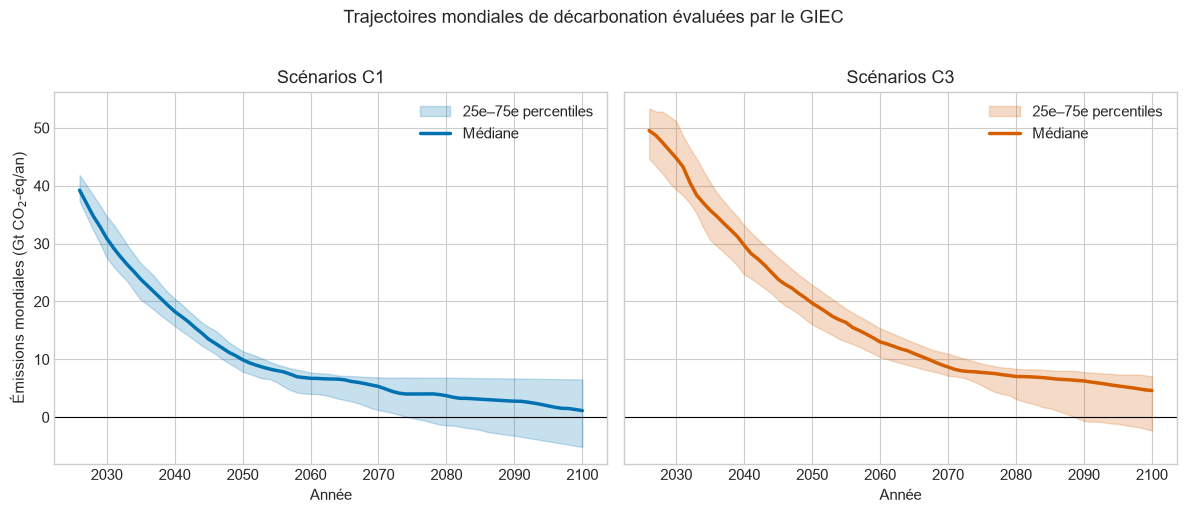

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
couleurs = {"C1": "#0072B2", "C3": "#D55E00"}

for ax, (categorie, donnees) in zip(axes, [("C1", c1), ("C3", c3)]):
    couleur = couleurs[categorie]
    ax.fill_between(
        donnees.index, donnees["p25"], donnees["p75"],
        color=couleur, alpha=0.22, label="25e–75e percentiles"
    )
    ax.plot(donnees.index, donnees["Median"], color=couleur, lw=2.5, label="Médiane")
    ax.axhline(0, color="black", lw=0.8)
    ax.set(title=f"Scénarios {categorie}", xlabel="Année")
    ax.legend()

axes[0].set_ylabel(r"Émissions mondiales (Gt CO$_2$-éq/an)")
fig.suptitle("Trajectoires mondiales de décarbonation évaluées par le GIEC", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "01_trajectoires_c1_c3.png", dpi=180, bbox_inches="tight")
plt.show()

### Relier les trajectoires au passé

Le fichier historique contient les émissions annuelles de GES, usage des sols inclus, en tonnes de CO₂-éq. Nous sélectionnons l'agrégat mondial et convertissons les tonnes en gigatonnes.

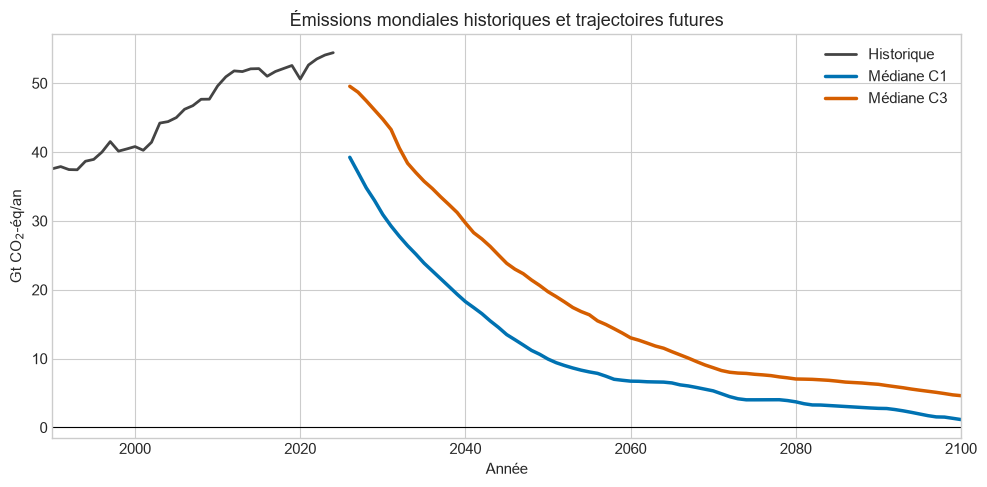

In [4]:
emissions_brutes = pd.read_csv(DONNEES / "greenhouse-gas-emissions.csv")
emissions_mondiales = (
    emissions_brutes.loc[emissions_brutes["Code"] == "OWID_WRL"]
    .set_index("Year")["Annual greenhouse gas emissions including land use"]
    .div(1e9)
)

fig, ax = plt.subplots(figsize=(10, 5))
emissions_mondiales.loc[1990:].plot(ax=ax, color="#444444", lw=2, label="Historique")
c1["Median"].plot(ax=ax, color=couleurs["C1"], lw=2.5, label="Médiane C1")
c3["Median"].plot(ax=ax, color=couleurs["C3"], lw=2.5, label="Médiane C3")
ax.axhline(0, color="black", lw=0.8)
ax.set(
    title="Émissions mondiales historiques et trajectoires futures",
    xlabel="Année", ylabel=r"Gt CO$_2$-éq/an", xlim=(1990, 2100)
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "01_historique_et_medianes.png", dpi=180, bbox_inches="tight")
plt.show()

In [5]:
annees_repere = [2026, 2030, 2040, 2050]
comparaison = pd.DataFrame(
    {"C1": c1.loc[annees_repere, "Median"], "C3": c3.loc[annees_repere, "Median"]}
)
comparaison.index.name = "année"
comparaison.columns.name = "médiane (Gt CO₂-éq/an)"
comparaison.round(1)

médiane (Gt CO₂-éq/an),C1,C3
année,,
2026,39.2,49.5
2030,30.9,44.8
2040,18.3,29.7
2050,9.9,19.7


**Questions d'interprétation.**

1. À partir de quelle année les médianes C1 et C3 divergent-elles nettement ?
2. Que masque l'utilisation de la seule médiane ?
3. Une valeur mondiale négative autorise-t-elle un pays ou un secteur à continuer d'augmenter ses émissions ? Pourquoi ?
4. Quels choix de périmètre rendent délicate la jonction entre la série historique et les scénarios ?

## 4. Décliner la trajectoire mondiale à une échelle plus fine

Pour une entité $i$ et une année $t$, la forme la plus simple d'une descente d'échelle est :

$$B_{i,t} = s_{i,t} \times B_{monde,t}$$

où $B_{monde,t}$ est le budget écologique mondial compatible avec la trajectoire retenue, et $s_{i,t}$ le ratio qui en attribue une part à l'entité. La définition de $s_{i,t}$ soulève des questions techniques, mais aussi des questions de justice. Trois principes contrastés seront calculés dans le prochain notebook :

| Principe | Exemple de variable d'allocation | Logique | Question critique |
|---|---|---|---|
| Égalité | part de la population mondiale | chaque personne reçoit la même part | ignore-t-on les émissions passées et les besoins ? |
| Maintien des droits acquis (*grandfathering*) | part actuelle des émissions | la transition prolonge la répartition existante | avantage-t-on les grands émetteurs ? |
| Capacité à agir | population pondérée par l'inverse du revenu | les entités les moins favorisées reçoivent une part plus importante | comment mesurer la capacité et choisir les seuils ? |

> Un principe de partage n'est pas un simple paramètre technique. Il traduit une certaine conception de l'égalité, de la responsabilité, des besoins ou de la capacité à agir.

## 5. Pistes pour le poster final

Durant le projet, les différentes facettes de la méthode pourront être explorées :

- entité étudiée : pays, secteur industriel ou individus ;
- trajectoire mondiale retenue : C1, C3 ou comparaison des deux ;
- indicateur retenu et périmètre de calcul des impacts ;
- année de départ et horizon ;
- principes de partage à comparer ;
- effets distributifs de chaque principe : quelles entités sont avantagées ou désavantagées ? ;
- incertitudes et limites des données.

**Mini-livrable.** Rédigez trois phrases : (1) votre unité d'analyse, (2) la différence entre une trajectoire C1 et C3 pour votre question, (3) le conflit éthique que vous pensez rencontrer lors de la descente en échelle.

### Références de départ

- Service des données et études statistiques (SDES), [*La France face aux neuf limites planétaires — Quelles utilisations du cadre des limites planétaires à l'échelle locale ?*](https://www.statistiques.developpement-durable.gouv.fr/edition-numerique/la-france-face-aux-neuf-limites-planetaires/partie3-quelles-utilisations-du-cadre-des-limites).
- European Environment Agency & FOEN (2020), *Is Europe living within the limits of our planet?* — copie locale dans `doc/`.
- Steffen et al. (2015), *Planetary boundaries: Guiding human development on a changing planet*, Science.
- IPCC (2022), *Climate Change 2022: Mitigation of Climate Change*, contribution du groupe III au sixième rapport d'évaluation.
- Données historiques : Our World in Data, fichier fourni dans `data/raw`.